## Question 01 ##

### (a) ###

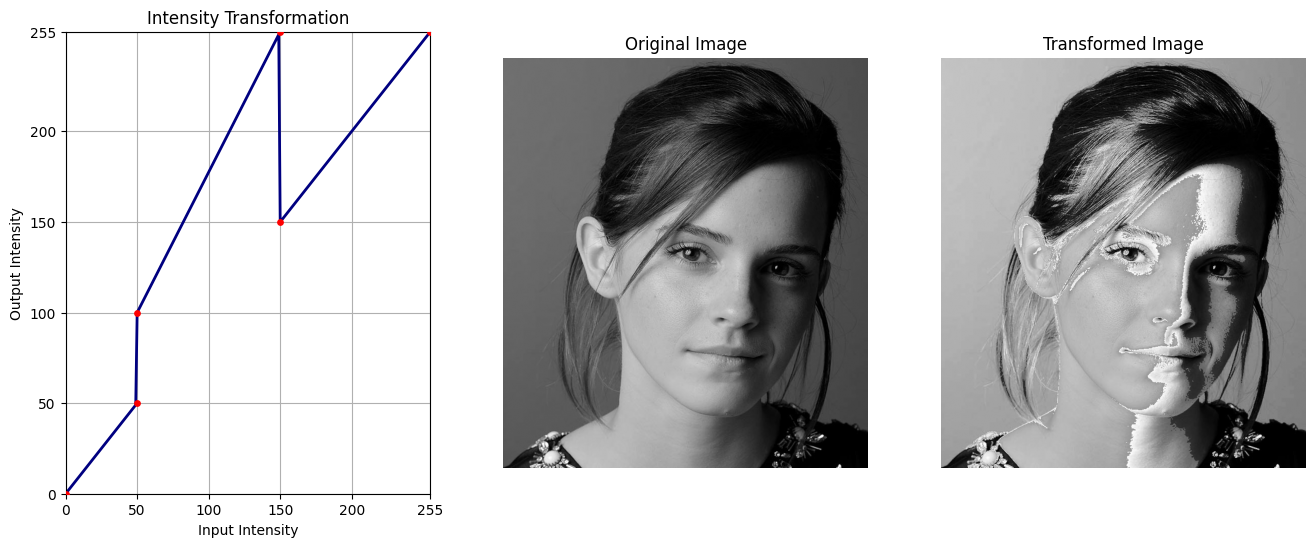

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def intensity_transform(im, breakpoints):
    """
        Here I defined the intensity transformation function to precompute values for 
        each pixel value in the range [0, 255] and store them in a lookup table, 
        since it is much faster than computing value for the pixel value each time.
            
    """
    out = im.copy().astype(float)

    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x2 == x1:
            continue # skips vertical lines as no need of computing slope there.
        else:
            slope = (y2 - y1) / (x2 - x1)
            mask = (im >= x1) & (im <= x2)
            out[mask] = y1 + slope * (im[mask] - x1)

    return out

path = "images/emma_gray.jpg"
im = np.array(Image.open(path).convert('L'))

breakpoints = [
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
]

out = intensity_transform(im, breakpoints)

xs = np.arange(0, 256)
lut = intensity_transform(xs, breakpoints)

bp = np.array(breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(16, 6))

ax[0].plot(xs, lut, color='navy', linewidth=2)
ax[0].scatter(bp[:, 0], bp[:, 1], color='red', s=15, zorder=5)
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_title('Intensity Transformation')
ax[0].set_xlim(0, 255); ax[0].set_ylim(0, 255)
ax[0].set_xticks([0, 50, 100, 150, 200, 255]); ax[0].set_yticks([0, 50, 100, 150, 200, 255])
ax[0].grid()

ax[1].imshow(im, cmap='gray')
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(out.astype(np.uint8), cmap='gray')
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.show()

In [31]:
def plot_transform(im, breakpoints, index=1):

    """
    This was created to simplify the plottings in experiments
    """
    out = intensity_transform(im, breakpoints)

    xs = np.arange(0, 256)
    lut = intensity_transform(xs, breakpoints)

    bp = np.array(breakpoints)

    ax = plt.subplots(1, 3, figsize=(16, 6))

    ax[0].plot(xs, lut, color='navy', linewidth=2)
    ax[0].scatter(bp[:, 0], bp[:, 1], color='red', s=15, zorder=5)
    ax[0].set_xlabel('Input Intensity')
    ax[0].set_ylabel('Output Intensity')
    ax[0].set_title('Intensity Transformation')
    ax[0].set_xlim(0, 255); ax[0].set_ylim(0, 255)
    ax[0].set_xticks([0, 50, 100, 150, 200, 255]); ax[0].set_yticks([0, 50, 100, 150, 200, 255])
    ax[0].grid()

    ax[1].imshow(im, cmap='gray')
    ax[1].set_title('Original Image')
    ax[1].axis('off')

    ax[2].imshow(out.astype(np.uint8), cmap='gray')
    ax[2].set_title(f'Transformed Image {index}')
    ax[2].axis('off')

    plt.show()

    return out

### (b) ###

I have done multiple experiments with different breakpoints and some with guessing and with analysing the histogram of the original image. There I found that the the Transformed image 3 have the most visually pleasing image output which was found by using the S-curve technique where I fletten out the too dark and too bright features to get more range to important details. Shortlisted bp-arrays and respective outputs (including the best one) are listed bellow.

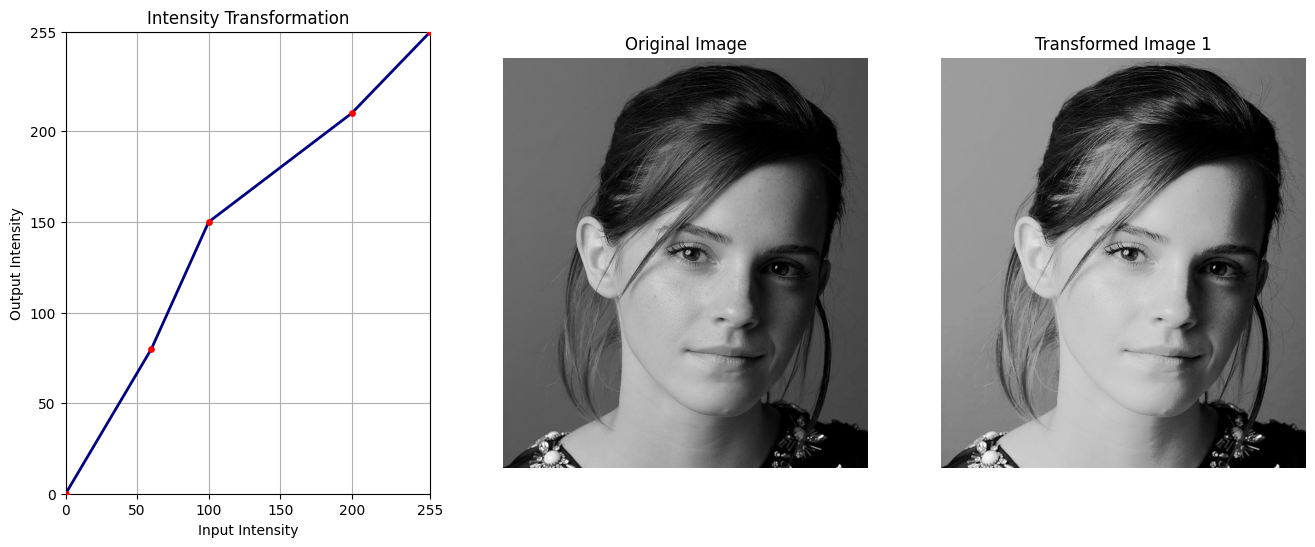

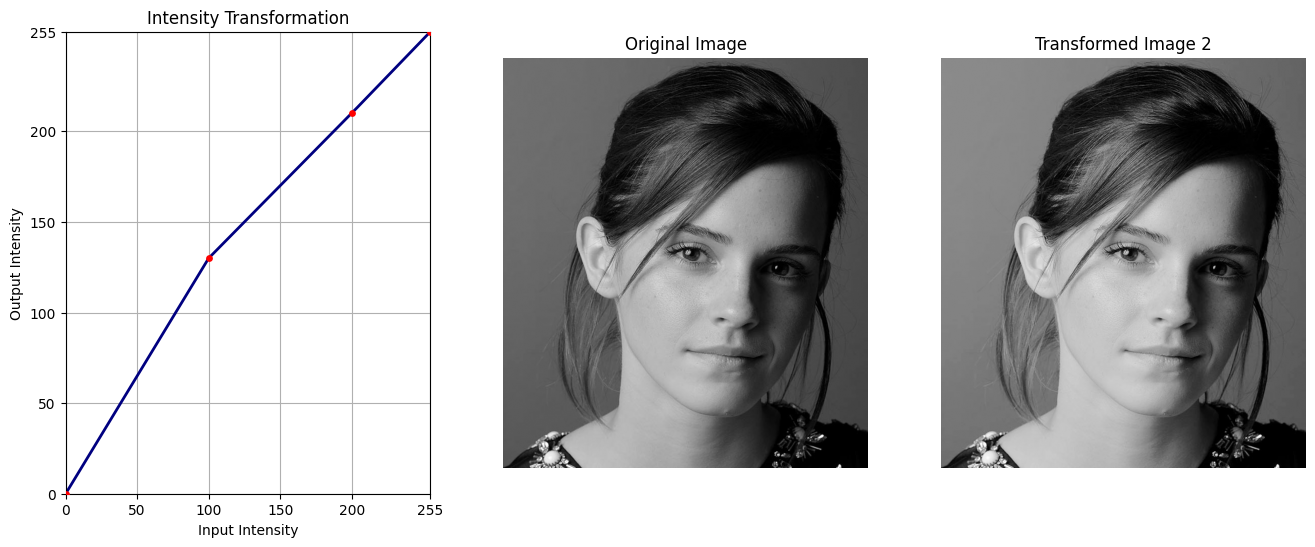

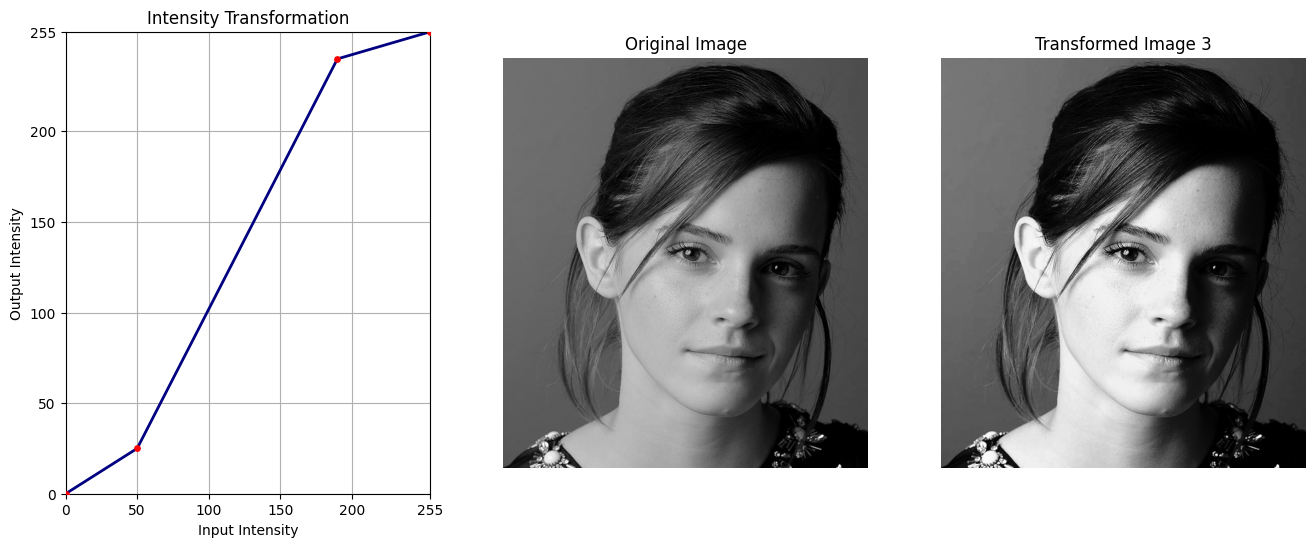

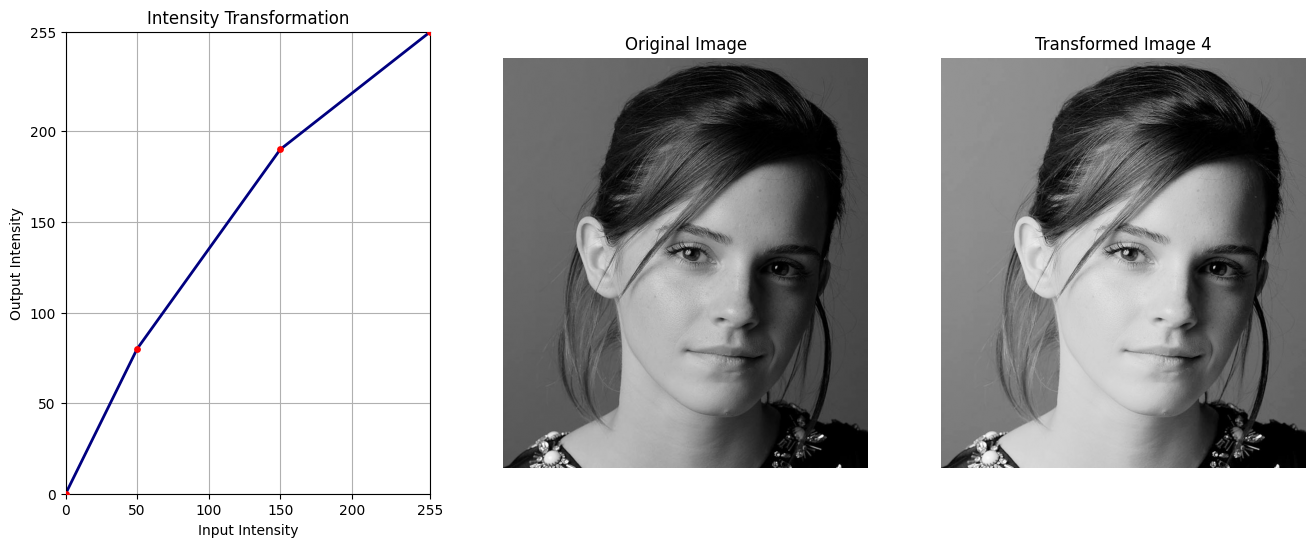

In [28]:
#plt.hist(im.ravel(), bins=256, range=(0,255))
#plt.show() #histogram of the original image

breakpoints_1= [[0, 0], [60, 80], [100, 150], [200, 210], [255, 255]]
out1 = plot_transform(im, breakpoints_1,1)

breakpoints_2= [[0, 0], [100, 130], [200, 210], [255, 255]]
out2 = plot_transform(im, breakpoints_2,2)

breakpoints_3= [[0, 0], [50, 25], [190, 240], [255, 255]]
out3 = plot_transform(im, breakpoints_3,3)

breakpoints_4= [[0, 0], [50, 80], [150, 190], [255, 255]]
out4 = plot_transform(im, breakpoints_4,4)


### Comparisson, Intepretation and Disscussion ###

The given breakpoints in the original transformation, introduce a discontinuity at intensity 150, causing pixels just below and just above this threshold to be mapped to very different output values. This is what produces that  false edge in part (a).

With respect to other experimented outputs (which avoided discontinuities), Transformation 3 is more visually pleasing. This is because in there the features that needs to be highlighted are highlighted and given a brader range to display fine textures(skin texture, hair strands, etc.) more acurately while smoothely flattening out the brightest and darkest pixels.

This confirms that breakpoint placement should be guided by where detail is concentrated in the image's intensity distribution, rather than applied uniformly. Steepening the curve over the dominant intensity range increases local contrast and perceptual sharpness, while flattening it at the extremes avoids introducing noise or losing information in already low-detail regions.

## Question 02 ##